# Trajectory and velocity analysis of scRNAseq COLON data 

This is one in the series of notebooks presenting the data analysis done in the study "Widespread epithelial dedifferentiation in patients with ulcerative colitis". It is also intended as a tutorial in scRNAseq analysis. Please refer to the REAMDE file for the description of different parts of the tutorial and how to follow it.  

## Part 5. RNA velocity

This is the fifth part of the guide in which we calculate the RNA velocity and explore different possibilities in how to present it. We also plot latent time, an alternative to pseudotime, grounded in RNA velocity.

### Healthy dataset

This notebook shows the pipeline done on the "Healthy dataset" (see study for details regarding samples constituting the dataset). Here I am explaining the procedure step by step, so hopefully one can repeat it on their own data. In this repository there are also notebooks showing the same pipeline for other datasets from the study. I am not repeating the descriptions in those, so please always refer to the "Healthy dataset" notebooks while following the tutorial. 

Here I am working on 4 samples which I want to merge together into one condition - Healthy. You need to adjust the code accordingly to the number of samples/conditions you're working on. 

#### 0. Imports and settings

In [1]:
import scanpy as sc
import scvelo as scv
import numpy as np

In [2]:
scv.settings.set_figure_params('scvelo', dpi=75, vector_friendly=True, figsize=[6,6])

#### 1. Load data

First lets load the file we have prepared in the previous part of the tutorial.

In [3]:
adata = sc.read('healthy_de.h5ad')

#### 2. Velocity computation

In this step we are calculating the RNA velocity based on the spliced and unspliced matrices of counts that we kept in our `adata` object from the very begining. We are using scVelo's full dynamical model as it has been shown to recover the differentiation trajectories more faithfully. It adapts RNA velocity to widely varying specifications such as non-stationary populations, as it does not rely on the restrictions of a common splicing rate or steady states to be sampled. 

First step is to compute first order moments for spliced and unspliced counts. Then it is to recover the full splicing kinetics of specified genes. While contructing the model, scVelo infers transcription rates, splicing rates, degradation rates, as well as cell-specific latent time and transcriptional states (to access some of those we need to use additional `.tl` functions).

By specifying the number of PCs and cell neighbors in the `scv.pp.moments()` function, we are ensuring the algorithm will reuse the previous results, instead of calculating them anew.

The `tl.recover_dynamics` is the most time consuming step out of the whole pipeline. It easily take 1 hour for moderate size dataset (10k cells). Among others, this calculation is used for:
- calculating velocity in dynamical mode (here we use stochastic mode which approximates the results well enough)
- differential kinetics (see section below)
- prior when calculating PAGA trajectories (velocity_pseudotime is used by default).

If you are interested only in a basic valocity picture (for example during initial dataset exploration), you can speed up the analysis significantly by skipping the `recover_dynamics` step.

In [4]:
scv.pp.moments(adata, n_pcs=30, n_neighbors=20)
scv.tl.recover_dynamics(adata)
scv.tl.velocity(adata)

computing moments based on connectivities
    finished (0:00:17) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
recovering dynamics
    finished (0:58:30) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
computing velocities
    finished (0:00:18) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


#### 3. Differential Kinetic

Most single cell datasets are simple, containing only one differentiation trajcetory, where we can confidently assign singular root and end point of the lineage. However, in more complicated datasets, like this colon dataset, we will have multiple possible trajectories, where we would expect genes to show different kinetics across lineages. That means that in case of datasets with many lineages having only a single model may be suboptimal.

To address this, scVelo offers tools to test how likely genes are to display differential kinetics: "[...] *the dynamical model can be used to perform a likelihood-ratio test for differential kinetics. This way, we can detect clusters that display kinetic behavior that cannot be well explained by a single model of the overall dynamics. Clustering cell types into their different kinetic regimes then allows fitting each regime separately.*"

You can read more about the procedure [here](https://scvelo.readthedocs.io/DifferentialKinetics.html).

You can skip this step if your dataset does not require it.

In [5]:
top_genes = adata.var['fit_likelihood'].sort_values(ascending=False).index[:500]
scv.tl.differential_kinetic_test(adata, var_names=top_genes, groupby='Celltype')

testing for differential kinetics
    finished (0:03:22) --> added 
    'fit_diff_kinetics', clusters displaying differential kinetics (adata.var)
    'fit_pval_kinetics', p-values of differential kinetics (adata.var)


Now we can recalculate the velocity, this time taking differential kinetics into account. We also compute the velocity graph, which is similar to the previous graph we did (`tl.draw_graph`), but instead of measuring similarity based on distance, it measures it based on "[...] *how well a corresponding change in gene expression matches the predicted change according to the velocity.* " 

`mode_neighbors='connectivities'` yields a symmetric graph which can help when looking for terminal states (see next section). 

In [6]:
scv.tl.velocity(adata, diff_kinetics=True)
scv.tl.velocity_graph(adata, mode_neighbors='connectivities')

computing velocities
    finished (0:00:18) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph
    finished (0:00:22) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


#### 4. Latent time 

The latent time is more accurate than the diffusion base pseudotime and does not require us to specify the root cell manually. Instead, the the starting and ending points of the differentiation process are inferred by the model based on the transition matrix with `tl.terminal_states`.

In [7]:
scv.tl.terminal_states(adata)
scv.tl.latent_time(adata)

computing terminal states
    identified 1 region of root cells and 4 regions of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:00:10) --> added 
    'latent_time', shared time (adata.obs)


Since we have inferred the root cells and the end points in an unsupervised mamnner, it is best to inspect them on a UMAP plot. In this case we can see that they closely match what we would expect based on known biology. The advantage is that those have been mathematically inferred and do not carry the inferent bias of manual selection. 

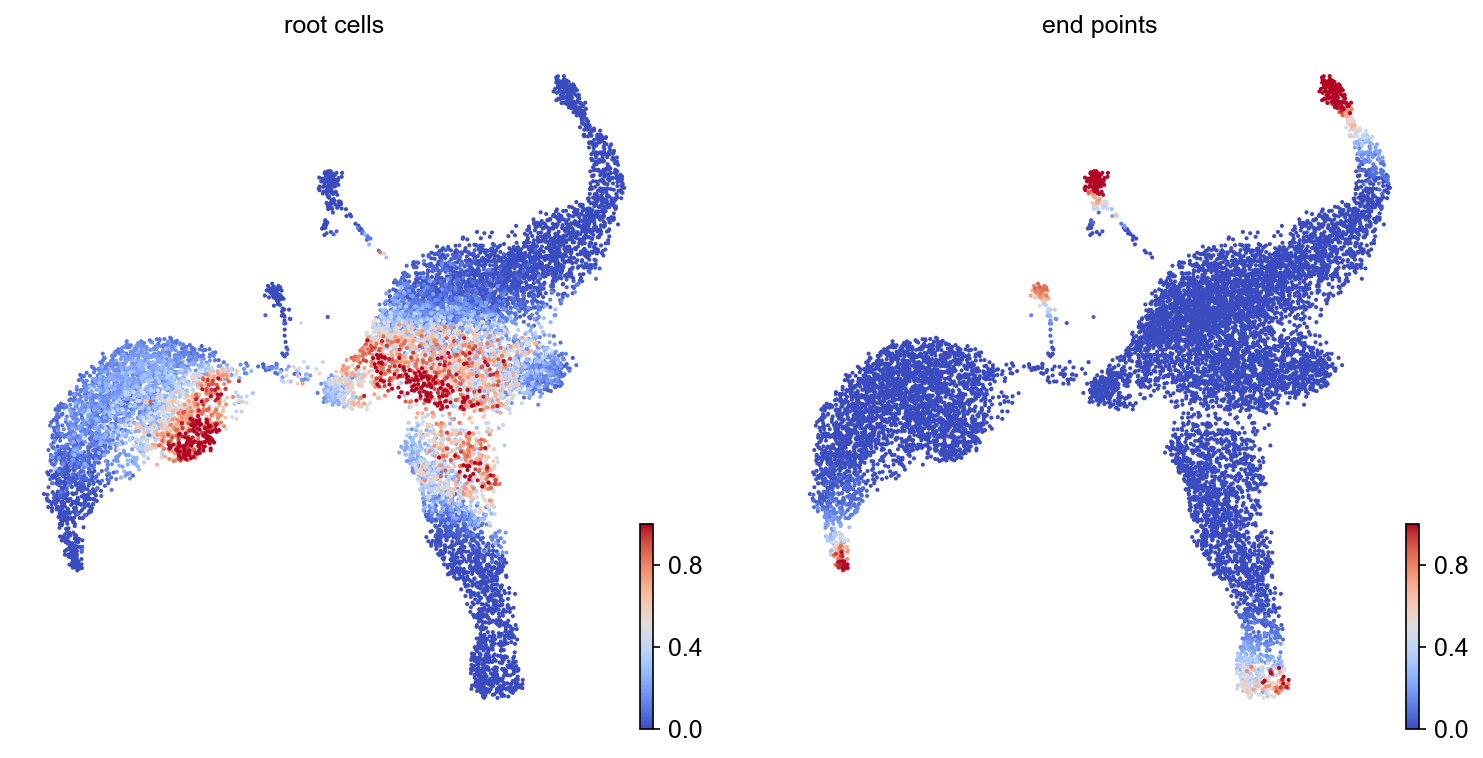

In [8]:
scv.pl.scatter(adata, color=['root_cells', 'end_points'], legend_loc='right margin',
               cmap='coolwarm', perc=[2, 98], colorbar=True, rescale_color=[0,1])

Finally, we can plot the latent time itself. In the plot below color is scaled between 2nd and 98th percentile to normalise extreme values in continous coloring. Again, we can see how it agrees with previous findings - the lowest values in the TA (cycling) populations and the highest in the crypt top terminal states. 

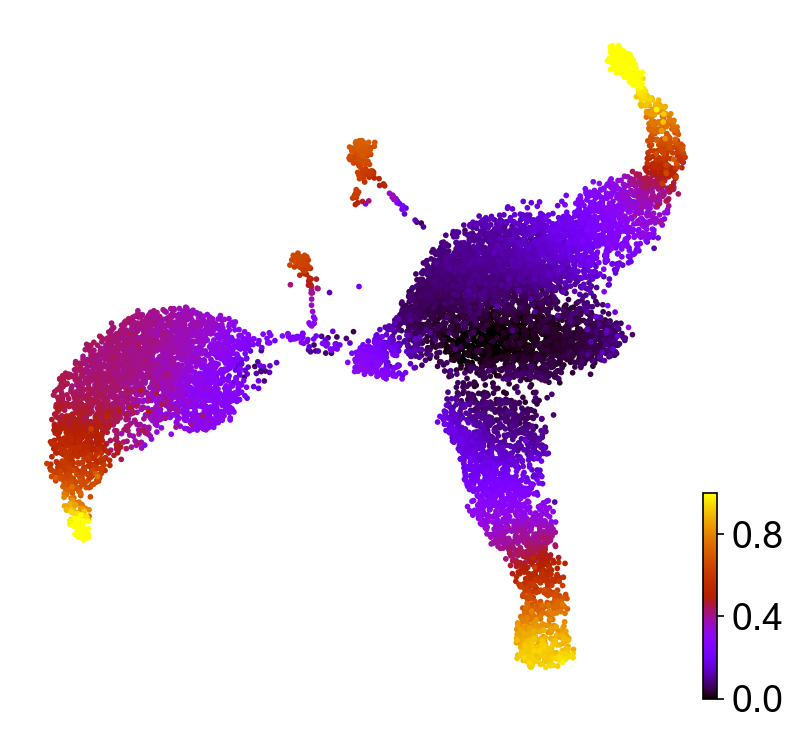

In [9]:
scv.pl.scatter(adata, color='latent_time', fontsize=24, size=30, basis='umap',
               color_map='gnuplot', perc=[2, 98], colorbar=True, rescale_color=[0,1],
               title='')

#### 5. Plotting velocity on embeddings

At last, let's plot the actual RNA velocity in the form of arrows.

We are offered a few different ways to present the velocity. We can change both the way velocity is visualised as well as the type of embedding it is displayed on. 

computing velocity embedding
    finished (0:00:02) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


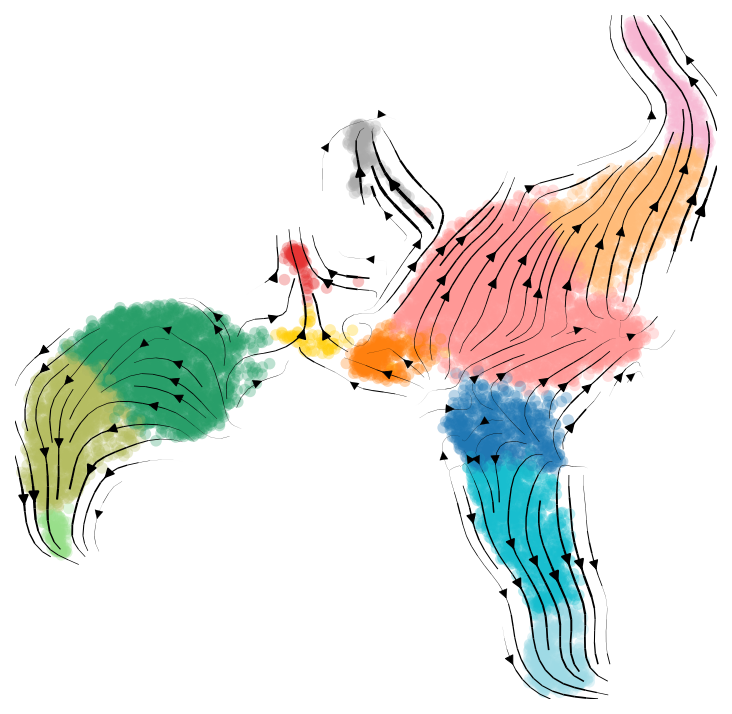

In [10]:
scv.pl.velocity_embedding_stream(adata, basis='umap', 
                                 legend_fontsize=10, title='', 
                                 smooth=.52, min_mass=0, color='Celltype',
                                 legend_loc='none')

computing velocity embedding
    finished (0:00:03) --> added
    'velocity_pca', embedded velocity vectors (adata.obsm)


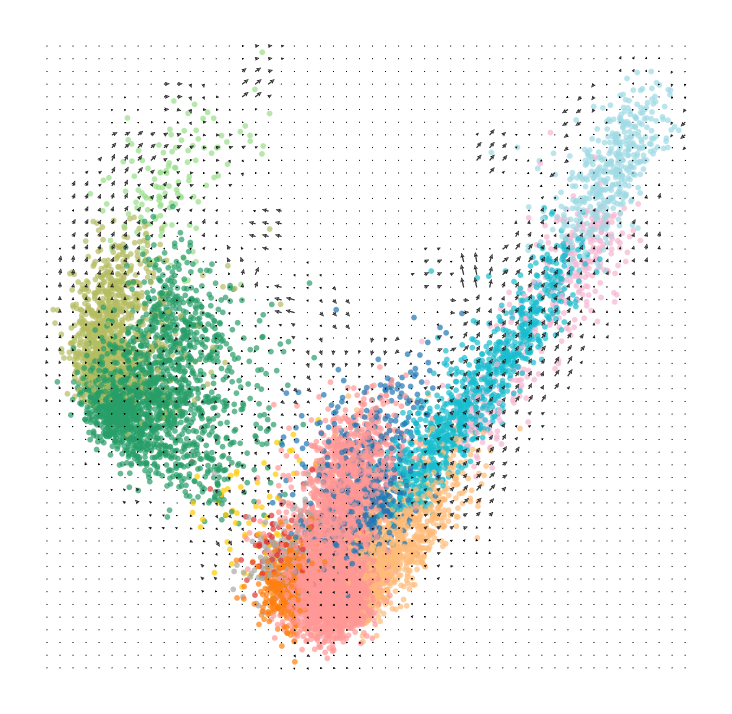

In [11]:
scv.pl.velocity_embedding_grid(adata, basis='pca', 
                                 legend_fontsize=10, title='', 
                                 smooth=.52, min_mass=0, color='Celltype',
                                 alpha=0.7, size=30, fontsize=30, legend_loc='none')

It may be informative to visualise the velocity vectors separately for each of the cells. I keep my images pretty small to be able to display them fast on github, but you may want to increase the image size to be able to see more details in the following picture. Simply increase the `dpi` parameter in `scv.settings.set_figure_params`.

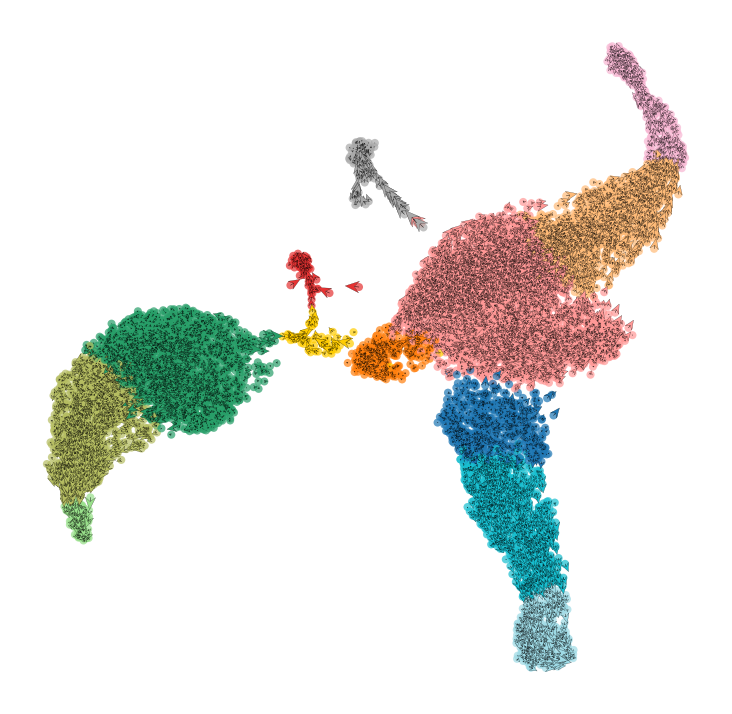

In [12]:
scv.pl.velocity_embedding(adata, basis='umap', 
                                 arrow_size=5, arrow_length=5, title='', 
                                 alpha=0.7, size=60, color='Celltype',
                                 legend_loc='none')

As before, it can be interesting to also explore the expression patterns of single genes overlaid with the velocity. 

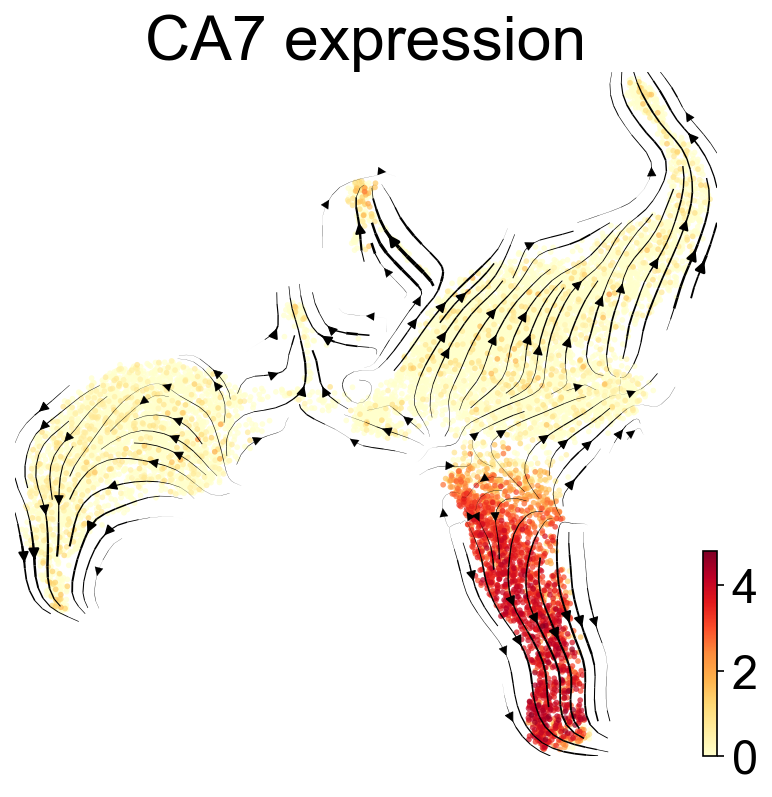

In [13]:
gene = "CA7"
scv.pl.velocity_embedding_stream(adata, basis='umap', cmap='YlOrRd',
                                 legend_fontsize=10, title='{} expression'.format(gene), 
                                 smooth=.52, min_mass=0, color=gene,
                                 alpha=0.7, size=30, fontsize=30, legend_loc='none')

#### 6. Velocity quality control

In my experience RNA velocity can heavily depend on your priors and mode of calculation. Therefore it is important to do a throughout check, whether all your results are coherent and agree with established knowledge. scVelo gives us another possibility to quality control through the `tl.velocity_confidence`. The function calculates two important statistics: velocity length, so the speed of differentiation measured by the length of the velocity vector and velocity confidence, a measure of how well neighbouring velocity vectors correlate with each other.

--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)


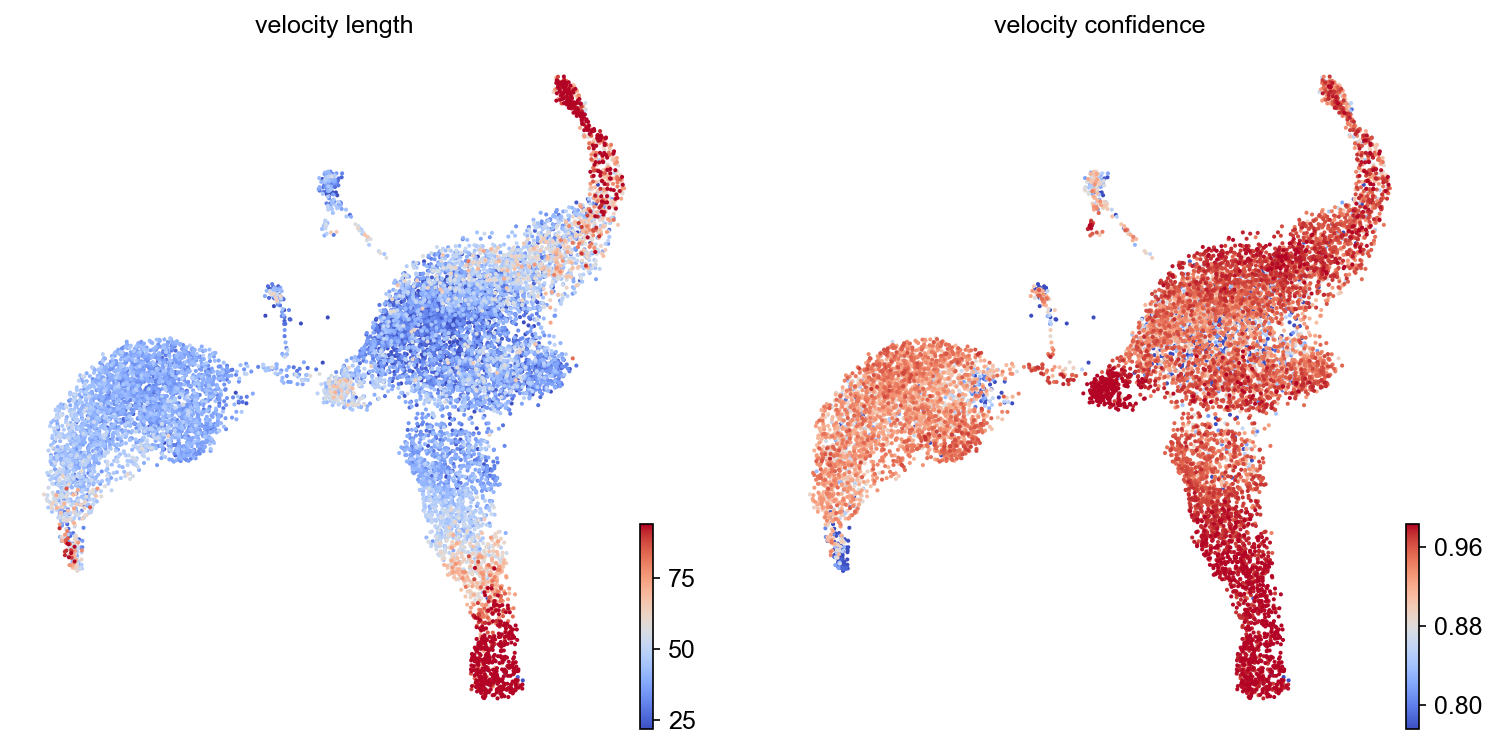

In [14]:
scv.tl.velocity_confidence(adata)
keys = 'velocity_length', 'velocity_confidence'
scv.pl.scatter(adata, c=keys, cmap='coolwarm', perc=[5, 95])

In this case we can see that cells differentiate at the fastest pace once they exit the cell cycle and are on track to become the fully matured, crypt top population. It is also good to see that we have a high velocity confidence across almost the whole dataset. The spots with lower confidence are the crypt top (where cells are begining to undergo apoptosis) and transit amplyfing cells (where cells are in the cell cycle), which is to be expected. 

We can also summarise those statistics into a table to check the velocity length and confidence across cell populations.

In [15]:
df = adata.obs.groupby('Celltype')[keys].mean().T
df.style.background_gradient(cmap='coolwarm', axis=1)

Celltype,Stem,TA SOX4+,TA Colonocytes,Colonocytes,CT Colonocytes,TA BEST4+,BEST4+,CT BEST4+,TA Goblet,Goblet,CT Goblet,EECs,Tuft
velocity_length,45.230495,40.625408,33.701469,49.082855,92.615067,36.393524,56.828751,110.882950,37.209194,43.414135,57.553360,35.529156,38.086761
velocity_confidence,0.965247,0.928276,0.890522,0.933085,0.937887,0.936838,0.972566,0.967551,0.915151,0.910003,0.683644,0.770570,0.866615


#### 7. PAGA velocity graph

Another useful way to represent the velocity field is by combining the RNA velocity and trajectory analyses. Using the scanpy/scVelo toolbox we have the oportunity to recalculate the PAGA trajectory graph using the velocity to calculate transition probabilities and inferr directionality in the PAGA graph.

In [16]:
# Those steps are currently necessary due to a bug in code. May change in future updates.
adata.uns['neighbors']['distances'] = adata.obsp['distances']
adata.uns['neighbors']['connectivities'] = adata.obsp['connectivities']

In [17]:
scv.tl.paga(adata, groups='Celltype', root_key='root_cells', end_key='end_points', use_time_prior=False)

running PAGA using priors: ['root_cells', 'end_points']
    finished (0:00:01) --> added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)


I have to note that the results in this section are very sensitive to the choice of priors, and in general, the parameter choices when calculating the dynamical model. Below, I'm presenting the best case scenario I got by optimising the parameters and priors to fit with other results from this analysis. You may want to experiment when analysing your dataset (for example use the latent time prior instead of root cells and end points).

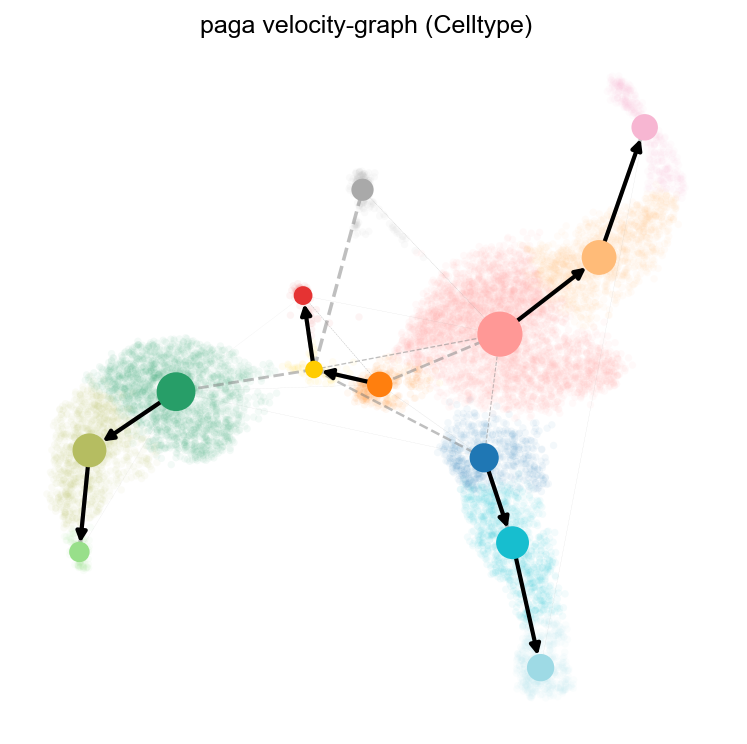

In [18]:
scv.pl.paga(adata, basis='umap', size=50, alpha=.05, color='Celltype',
            min_edge_width=2, node_size_scale=1, legend_loc='none', arrowsize=10)

In the plot above the nodes are the summarised Celltype clusters (as in the original PAGA graph), the dashed edges are the connectivites of the clusters (with edge weight representing the confidence in the presence of the connection) and the solid edges are the velocity directed transitions between the clusters. 

This plot quite nicely shows the clear transitions from TA to CT celltypes in each of the three main lineages. 

Since the Celltype clustering is very coarse, and may obfuscate some underlying variability, it may also be informative to visualise the transitions on the smaller *SubCelltype* clusters. 

In [19]:
scv.tl.paga(adata, groups='SubCelltype', root_key='root_cells', end_key='end_points', use_time_prior=False)

running PAGA using priors: ['root_cells', 'end_points']
    finished (0:00:01) --> added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)


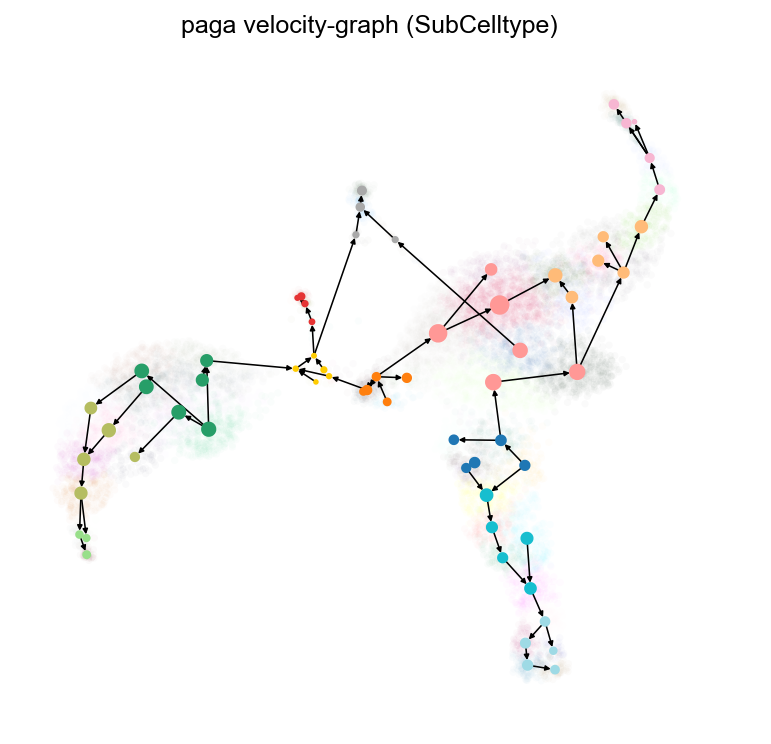

In [20]:
scv.pl.paga(adata, basis='umap', size=50, alpha=.02, color='Celltype', dashed_edges=None,
            min_edge_width=0.75, node_size_scale=0.2, legend_loc='none', arrowsize=5)

#### 8. Save data for the next step 

There's still more options to explore with the velocity calculations, for example finding cluster-specific genes driving the velocity. I highly recommend checking out the official scVelo's tutorials or going through their API documentation. 

For now we will finish and save the final object. Even if you don't plan any more analysis, it is a good idea to save given how long it takes to calculate the velocity. 

In [21]:
adata.write("healthy_velo.h5ad")